<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

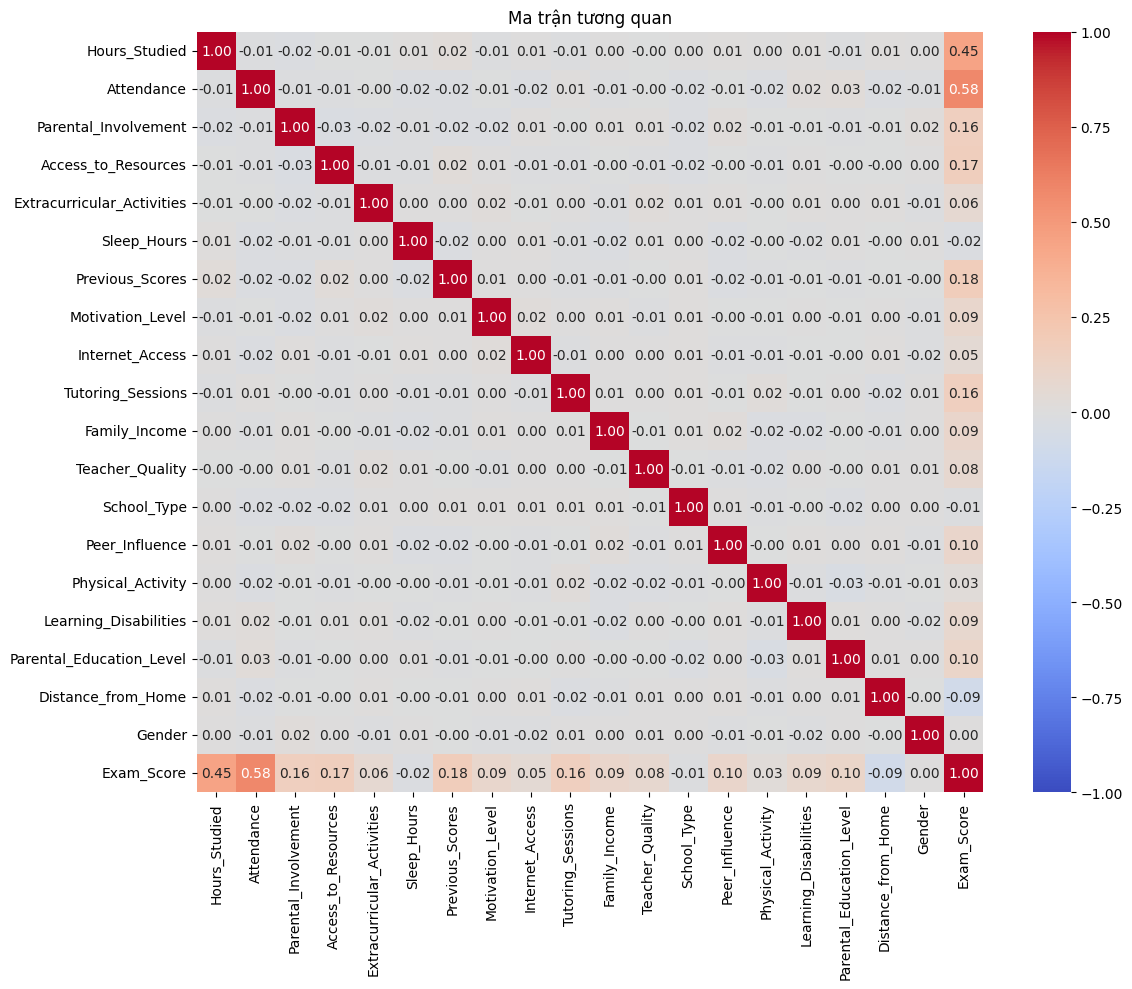

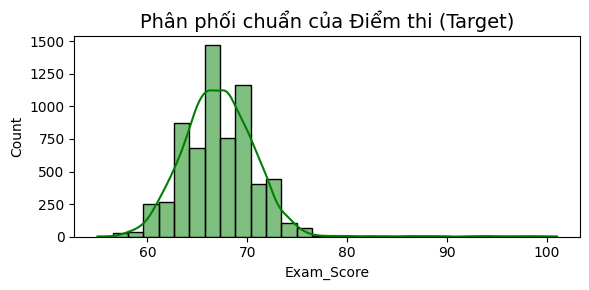

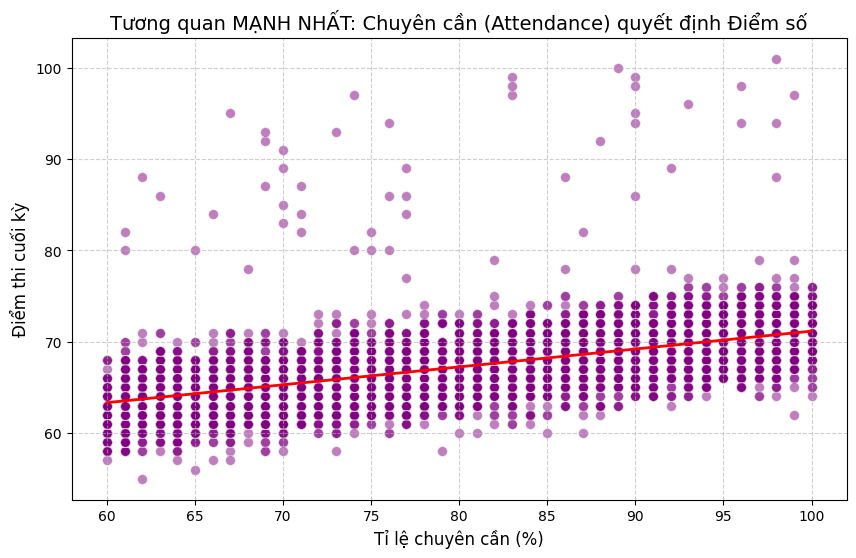


--- KẾT QUẢ ĐÁNH GIÁ ---
1. R2 Score (Độ khớp): 0.7548
2. MAE (Sai số trung bình): 0.57 điểm
3. RMSE (Sai số chuẩn): 1.86 điểm


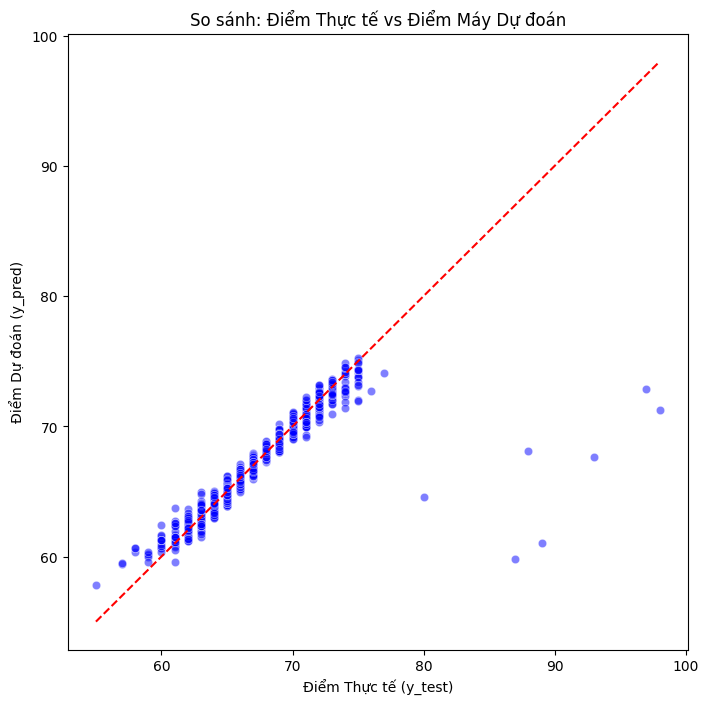

In [1]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
path="../data/StudentPerformance.csv"

#statistics

data=pd.read_csv(path)
data.info()
print(data.isnull().sum())
data.describe()

#preprocessing

# Xử lý các cột ordinal
 #1. Định nghĩa thứ tự
quality=["Low","Medium","High"]
distance=["Near","Moderate","Far"]
parent_edu_qual=['High School',"College","Postgraduate"]
peer_influence=["Negative","Neutral","Positive"]

 #2. Khởi tạo OrdinalEncodeer
encoder1=OrdinalEncoder(categories=[quality,parent_edu_qual,distance,peer_influence],handle_unknown="use_encoded_value",unknown_value=np.nan)
encoder2=OrdinalEncoder(categories=[quality]*4,handle_unknown="use_encoded_value",unknown_value=np.nan)

 #3. Áp dụng vào data
data[["Teacher_Quality","Parental_Education_Level","Distance_from_Home","Peer_Influence"]]=encoder1.fit_transform(data[["Teacher_Quality","Parental_Education_Level","Distance_from_Home","Peer_Influence"]])
data[["Family_Income","Motivation_Level","Access_to_Resources","Parental_Involvement"]]=encoder2.fit_transform(data[["Family_Income","Motivation_Level","Access_to_Resources","Parental_Involvement"]])

# Xử lý các cột nhị phân
binary_cols = ['Extracurricular_Activities', 'Internet_Access' ]
for col in binary_cols:
    data[col] = data[col].map({'Yes': 1, 'No': 0})

data["School_Type"]=data["School_Type"].map({"Private":0,"Public":1})
data["Gender"]=data["Gender"].map({"Male":0, "Female":1})
data['Learning_Disabilities']=data['Learning_Disabilities'].map({"Yes":0, "No":1})

    


# Xuất file CSV
data.to_csv('processed_student_performance.csv', index=False)

#Visualization
plt.figure(figsize=(12,10))
correlation=data.corr()
sn.heatmap(correlation,cmap="coolwarm",annot=True,fmt=".2f",vmin=-1,vmax=1)
plt.title("Ma trận tương quan")
plt.tight_layout()

plt.figure(figsize=(6,3))
sn.histplot(data["Exam_Score"], kde=True,color='green', bins=30)#type:ignore
plt.title('Phân phối chuẩn của Điểm thi (Target)', fontsize=14)
plt.tight_layout()
plt.figure(figsize=(10, 6))

# Vẽ Scatter Plot: Attendance (Trục X) vs Exam Score (Trục Y)
# alpha=0.5: Làm mờ các điểm để thấy chỗ nào tập trung đông
sn.scatterplot(x='Attendance', y='Exam_Score', data=data, color='purple', alpha=0.5, s=50)

# Vẽ thêm đường Hồi quy tuyến tính (Regression Line) màu đỏ
# Nếu đường này dốc đứng lên -> Tương quan càng mạnh
sn.regplot(x='Attendance', y='Exam_Score', data=data, scatter=False, color='red', line_kws={'linewidth': 2})

plt.title('Tương quan MẠNH NHẤT: Chuyên cần (Attendance) quyết định Điểm số', fontsize=14)
plt.xlabel('Tỉ lệ chuyên cần (%)', fontsize=12)
plt.ylabel('Điểm thi cuối kỳ', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6) # Thêm lưới mờ cho dễ nhìn

plt.show()

# Chia tập train và test
x=data.drop("Exam_Score",axis=1)
y=data["Exam_Score"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
# Xử lý các ô trống(mising value)
cols_with_nan = ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']
imputer=SimpleImputer(strategy='median');
x_train[cols_with_nan]=imputer.fit_transform(x_train[cols_with_nan])
x_test[cols_with_nan]=imputer.transform(x_test[cols_with_nan])
#chuẩn hóa
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

# HUẤN LUYỆN MÔ HÌNH (LINEAR REGRESSION)
model=SVR()
model.fit(x_train_scaled,y_train)

# Dự báo trên tập test
y_pred = model.predict(x_test_scaled)



# ĐÁNH GIÁ HIỆU QUẢ 
# 1. R2 Score: Độ chính xác tổng thể (Càng gần 1 càng tốt)
r2 = r2_score(y_test, y_pred)

# 2. MAE (Mean Absolute Error): Sai số tuyệt đối trung bình (Dễ hiểu nhất)
# Ví dụ: MAE = 2 nghĩa là dự đoán thường lệch khoảng 2 điểm
mae = mean_absolute_error(y_test, y_pred)

# 3. RMSE: Sai số bình phương trung bình (Phạt nặng các lỗi sai lớn)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"\n--- KẾT QUẢ ĐÁNH GIÁ ---")
print(f"1. R2 Score (Độ khớp): {r2:.4f}")
print(f"2. MAE (Sai số trung bình): {mae:.2f} điểm")
print(f"3. RMSE (Sai số chuẩn): {rmse:.2f} điểm")


# --- BƯỚC 4: VISUALIZATION (NHÌN BẰNG MẮT) ---
# Vẽ biểu đồ so sánh Giá trị Thực tế vs Dự đoán
plt.figure(figsize=(8, 8))
sn.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='blue')

# Vẽ đường chéo đỏ chuẩn (nếu dự đoán đúng 100% thì điểm sẽ nằm trên đường này)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.title('So sánh: Điểm Thực tế vs Điểm Máy Dự đoán')
plt.xlabel('Điểm Thực tế (y_test)')
plt.ylabel('Điểm Dự đoán (y_pred)')
plt.show()